In [26]:
import pandas as pd
df = pd.read_csv("Nigerian_Graduate_Survey_with_Salary.csv")
state = df['State_of_Origin']
df


,Graduate_ID,Age,Gender,State_of_Origin,Region,Urban_or_Rural,Household_Income_Bracket,Field_of_Study,University_Type,GPA_or_Class_of_Degree,Has_Postgrad_Degree,Years_Since_Graduation,Employment_Status,Salary_Level,Net_Salary
0,G0001,27,Male,Edo,North,Urban,Low,Engineering,Private,Second Class Lower,No,6,Employed,Low-paid,160183
1,G0002,24,Female,Oyo,North,Urban,Low,Engineering,State,Second Class Upper,No,8,Employed,Well-paid,386218
2,G0003,33,Male,Kano,North,Urban,Low,Business,Federal,Third Class,No,3,Employed,Well-paid,340689
3,G0004,31,Female,Lagos,South,Urban,Low,Business,State,Second Class Upper,No,6,Employed,Well-paid,346470
4,G0005,28,Female,Enugu,East,Rural,Middle,Business,Federal,Second Class Upper,Yes,8,Employed,Low-paid,52693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,G2996,25,Male,Lagos,North,Urban,Low,Engineering,Federal,Second Class Upper,No,2,Employed,Low-paid,90727
2996,G2997,22,Male,Lagos,West,Urban,Middle,Education,Federal,First Class,No,2,Unemployed,Not employed,0
2997,G2998,24,Male,Plateau,East,Urban,Middle,Education,State,First Class,No,0,Employed,Low-paid,64464
2998,G2999,29,Male,Edo,West,Urban,Middle,Business,State,Second Class Upper,No,9,Unemployed,Not employed,0


In [17]:
from scipy import stats
salary_df = df[(df['Employment_Status'] == 'Employed') & (df['Net_Salary'] > 0)].copy()
Lagos = salary_df[salary_df['State_of_Origin'] == 'Lagos']['Net_Salary']
Edo = salary_df[salary_df['State_of_Origin'] == 'Edo']['Net_Salary']
Kano = salary_df[salary_df['State_of_Origin'] == 'Kano']['Net_Salary']


In [18]:
p_edo = stats.ttest_ind(Lagos, Edo).pvalue
p_kan = stats.ttest_ind(Lagos, Kano).pvalue

In [19]:
print("--- T-Test Statistical Results ---")
print(f"Lagos vs Edo P-value: {p_edo:.3f}")
print(f"Lagos vs Kano P-value: {p_kan:.3f}")


--- T-Test Statistical Results ---
Lagos vs Edo P-value: 0.388
Lagos vs Kano P-value: 0.923


In [22]:
# Calculate the 90th percentile (Top 10% earners) for each city
df_three = df[df['State_of_Origin'].isin(['Lagos', 'Kano', 'Edo'])]
top_10_percent = df_three.groupby('State_of_Origin')['Net_Salary'].quantile(0.9)

print("Top 10% Salary by City:")
print(top_10_percent)

Top 10% Salary by City:
State_of_Origin
Edo      315059.0
Kano     333852.0
Lagos    325658.2
Name: Net_Salary, dtype: float64


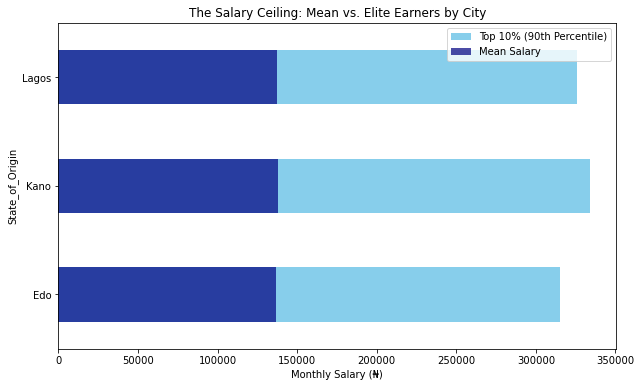

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data for the chart
means = df_three.groupby('State_of_Origin')['Net_Salary'].mean()
top_10 = df_three.groupby('State_of_Origin')['Net_Salary'].quantile(0.9)
means
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
top_10.plot(kind='barh', color='skyblue', label='Top 10% (90th Percentile)', ax=ax)
means.plot(kind='barh', color='navy', label='Mean Salary', ax=ax, alpha=0.7)

plt.title('The Salary Ceiling: Mean vs. Elite Earners by City')
plt.xlabel('Monthly Salary (₦)')
plt.legend()
plt.show()

In [27]:
print(f"The total number of graduates in my three-city study is: {len(df_three)}")

The total number of graduates in my three-city study is: 907
